<a href="https://colab.research.google.com/github/27Kushal/PyTorch-learning/blob/main/pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Importing Pytorch and setting up device agnostic code


In [ ]:
import torch
from torch import nn

torch.__version__

'2.11.0+cpu'

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

#1. Get Data

Our data is a subset of Food101 dataset.

Food101 starts with 101 different classes of food and 1000 images per class(750 training, 250 testing)

Our dataset starts with 3 classes of food and only 10% of the images(75 training and 25 testing)

It is beneficial because we should try on small scale and then increase the scale when necessary. It speeds up the experimentation process.

In [ ]:
import requests
import zipfile
from pathlib import Path

#setup path to a data folder
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

#if the image folder doesn't exist, download and prepare it
if image_path.is_dir():
  print(f"{image_path} directory already exists, skipping download")
else:
  print(f"{image_path} does not exist, creating one")
  image_path.mkdir(parents=True,exist_ok=True)

#download data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloadig pizza,steak and sushi data")
  f.write(request.content)

#unzip data
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping pizza,steak sushi data")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi does not exist, creating one
Downloadig pizza,steak and sushi data
Unzipping pizza,steak sushi data


#2. Becoming one with the data(data preparation and data exploration)

In [ ]:
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning its contents"""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi.
There are 3 directories and 0 images in data/pizza_steak_sushi/train.
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza.
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak.
There are 3 directories and 0 images in data/pizza_steak_sushi/test.
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza.
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak.


In [ ]:
#setup train and testing paths
train_dir=image_path/"train"
test_dir=image_path/"test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

##2.1 Visualizing and image

Let's write code to:
1. get all of the image paths
2. pick a random image using python's random.choice()
3. get the image class name using "pathlib.Path.parent.stem"
4. since we are working with image, so using python's PIL library opening the image
5. We will show the image and print metadata

Image Path: data/pizza_steak_sushi/train/steak/214320.jpg
Image class: steak
Image height: 383
Image width: 512


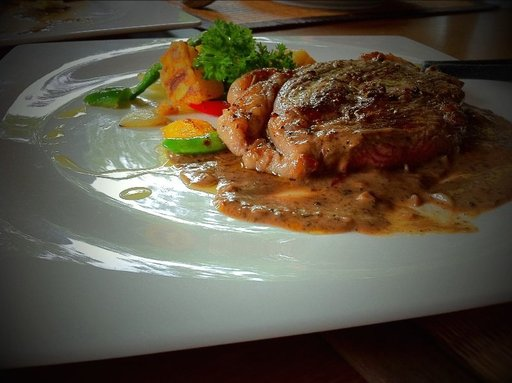

In [ ]:
import random
from PIL import Image


#1. get all image path
image_path_list=list(image_path.glob("*/*/*.jpg")) #1st * represents train/test 2nd * represents the type and 3rd represents the image name

#2. pick a random image path
random_image_path=random.choice(image_path_list)

#3. get image class from the pathname
image_class=random_image_path.parent.stem

#4. open image
img=Image.open(random_image_path)

#5. print metadata
print(f"Image Path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(382.5), np.float64(-0.5))

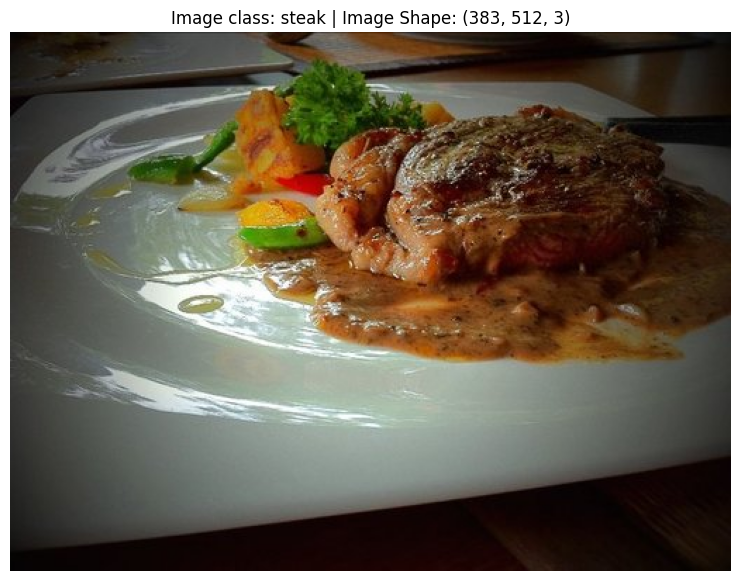

In [ ]:
#visualizing the data using matplotlib
import numpy as np
import matplotlib.pyplot as plt

#turn the image into array
img_to_array=np.asarray(img)
#plot the image using matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_to_array)
plt.title(f"Image class: {image_class} | Image Shape: {img_to_array.shape}") #shape->[height,width,colour channel]
plt.axis(False)

#3. Transforming data

before we use our image with Pytorch:
1. turn target data into tensors (numerical representation of our images)
2. turn it into torch.utils.data.Dataset and subsequently into torch.utils.data.DataLoader, we call these dataset and dataloader
3.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

##3.1 Transforming data using torchvision.transforms

Transforms help you get your images ready to be used with a model/perform sata augmentation

In [ ]:
#write a transform for image
data_transform=transforms.Compose([ #compose is used to
    #resize the images to 64*64
    transforms.Resize(size=(64,64)),
    #flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    #turn the image to torch tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape

torch.Size([3, 64, 64])

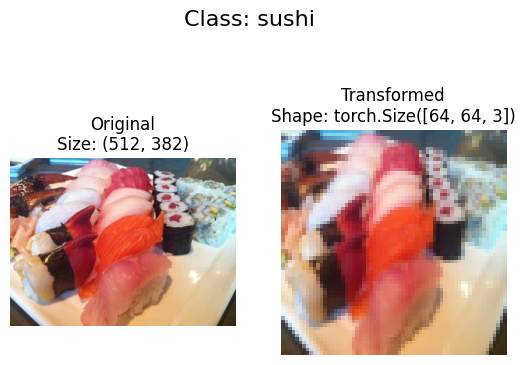

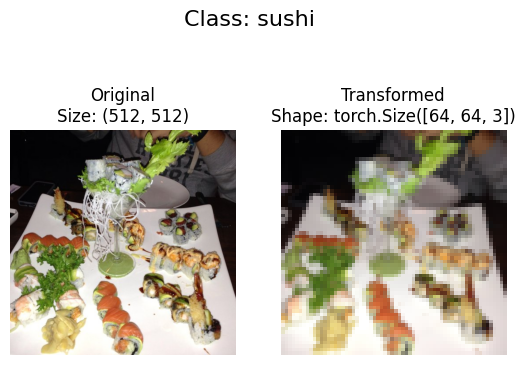

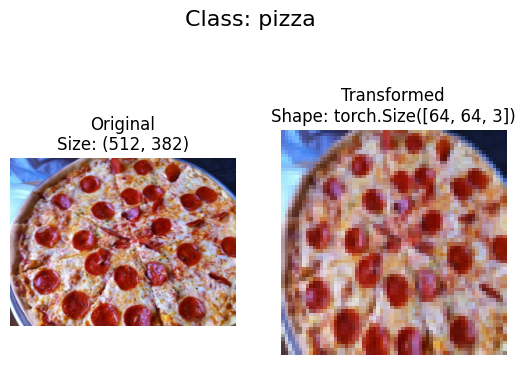

In [ ]:
def plot_transformed_images(image_paths:list,transform,n=3,seed=None):
  """
  Selects random images from a path of images and loads/transforms them
  then plots the original vs the transformed version
  """
  if seed:
    random.seed(seed)
  random_image_paths=random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig,ax=plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      #transform and plot target image
      transformed_image=transform(f).permute(1,2,0)
      #note we will need to change shape for matplotlib as it wants colour channels at the end whereas we have it in the front
      #(C,H,W)->(H,W,C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis(False)

      fig.suptitle(f"Class: {image_path.parent.stem}",fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)

#4. Option 1: Loading image data using ImageFolder

We can load image classification data using torchvision.datasets.ImageFolder


In [ ]:
#use ImageFolder to create dataset
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transform, #transform for the data
                                target_transform=None) #transform for the label/target

test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
#get class names as dict
class_dict=train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
#check the lengths of the dataset
len(train_data),len(test_data)

(225, 75)

In [ ]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [ ]:
#index on the train_data Dataset to get single image and label
img,label=train_data[0][0],train_data[0][1]
print(f"Image tensor:\n{img}")
print(f"Image Shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [ ]:
#rearrange the order dimension
img_permute=img.permute(1,2,0)
#print out different shapes
print(f"Original shape:{img.shape}->[colour channels,height,width]")
print(f"Image permute: {img_permute.shape}->[height,width,colour channels]")

#plot the image

Original shape:torch.Size([3, 64, 64])->[colour channels,height,width]
Image permute: torch.Size([64, 64, 3])->[height,width,colour channels]
